# <center> **Web Scraping**

# Préambule

In [1]:
### Bibliothèque ###

from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("../data")
FIGURE_DIR = Path("../figure")
TABLE_DIR = Path("../table")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
### Chargement des données ###

df = pd.read_csv(DATA_DIR / "chats_dataset.csv", sep=",")
print(df.head())

               Espèce          Origine          Caractère  Trait distinctif  \
0             Abyssin  Égypte ancienne     Actif, curieux     Marques tabby   
1  American Shorthair       États-Unis      Amical, calme   Musclé, robuste   
2         Angora Turc          Turquie  Doux, intelligent       Pelage long   
3            Balinais       États-Unis    Sociable, vocal  Pointes colorées   
4              Bengal       États-Unis  Énergique, joueur   Taches sauvages   

  Niveau d'activité     Santé Relations enfants Entretien du pelage  \
0             Élevé   Robuste          Sociable              Modéré   
1            Modéré     Bonne         Excellent              Faible   
2            Modéré  Sensible        Affectueux               Élevé   
3             Élevé     Bonne            Amical              Modéré   
4        Très élevé   Robuste             Actif              Faible   

  Type de pelage Robe et couleurs   Poids   Taille Espérance de vie  \
0          Court      Fauve

# Data Cleaning

In [3]:
### Nettoyage ###

df[['Poids min (kg)', 'Poids max (kg)']] = (
    df['Poids']
    .str.replace("kg", "", regex=False)
    .str.split('-', expand=True)
)

df[['Espérance de vie min', 'Espérance de vie max']] = (
    df['Espérance de vie']
    .str.replace("ans", "", regex=False)
    .str.split('-', expand=True)
)

cols_num = [
    'Poids min (kg)', 'Poids max (kg)',
    'Espérance de vie min', 'Espérance de vie max'
]
df[cols_num] = df[cols_num].astype(float)
df = df.drop(columns=['Poids', 'Espérance de vie'])

df["Continent"] = df["Origine"]

Afrique = ["Égypte ancienne"]
Asie = ["Turquie", "Russie", "Birmanie", "Japon", "Thaïlande", "Iran", "Singapour"]
Europe = ["Royaume-Uni", "France", "Europe", "Norvège", "Écosse"]
Amerique = ["États-Unis", "Canada"]

df.loc[df["Origine"].isin(Afrique), "Continent"] = "Afrique"
df.loc[df["Origine"].isin(Asie), "Continent"] = "Asie"
df.loc[df["Origine"].isin(Europe), "Continent"] = "Europe"
df.loc[df["Origine"].isin(Amerique), "Continent"] = "Amérique"

df["Caractère_1"] = df["Caractère"].str.split(", ").str[0]
df["Caractère_2"] = df["Caractère"].str.split(", ").str[1]
 
df["Relations enfants"] = df["Relations enfants"].str.replace(" Amical", "Amical", regex=False)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Espèce                39 non-null     object 
 1   Origine               39 non-null     object 
 2   Caractère             39 non-null     object 
 3   Trait distinctif      39 non-null     object 
 4   Niveau d'activité     39 non-null     object 
 5   Santé                 39 non-null     object 
 6   Relations enfants     39 non-null     object 
 7   Entretien du pelage   39 non-null     object 
 8   Type de pelage        39 non-null     object 
 9   Robe et couleurs      39 non-null     object 
 10  Taille                39 non-null     object 
 11  Lien PNG              39 non-null     object 
 12  Poids min (kg)        39 non-null     float64
 13  Poids max (kg)        39 non-null     float64
 14  Espérance de vie min  39 non-null     float64
 15  Espérance de vie max  39 

# Data Viz

In [4]:
### Statistiques descriptives ###

df_num = df.select_dtypes(include="number")
df_cat = df.select_dtypes(exclude="number")

print(df_num.describe())
print(df_cat.drop(columns=["Lien PNG"]).describe())

with pd.ExcelWriter(TABLE_DIR / "resume_statistique.xlsx") as writer:
    df_num.describe().to_excel(writer, sheet_name='Numerique')
    df_cat.drop(columns=["Lien PNG"]).describe().to_excel(writer, sheet_name='Categoriel')

       Poids min (kg)  Poids max (kg)  Espérance de vie min  \
count       39.000000       39.000000             39.000000   
mean         3.230769        5.666667             12.794872   
std          0.841726        1.344254              1.321472   
min          2.000000        4.000000             11.000000   
25%          3.000000        5.000000             12.000000   
50%          3.000000        5.000000             12.000000   
75%          4.000000        7.000000             14.000000   
max          5.000000        9.000000             16.000000   

       Espérance de vie max  
count             39.000000  
mean              16.487179  
std                1.971798  
min               14.000000  
25%               15.000000  
50%               16.000000  
75%               17.000000  
max               20.000000  
         Espèce     Origine        Caractère Trait distinctif  \
count        39          39               39               39   
unique       39          15     

In [5]:
### graphiques ###

sns.set_theme(style="whitegrid")

/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_18938/3649444948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x="Niveau d'activité", kind="count",


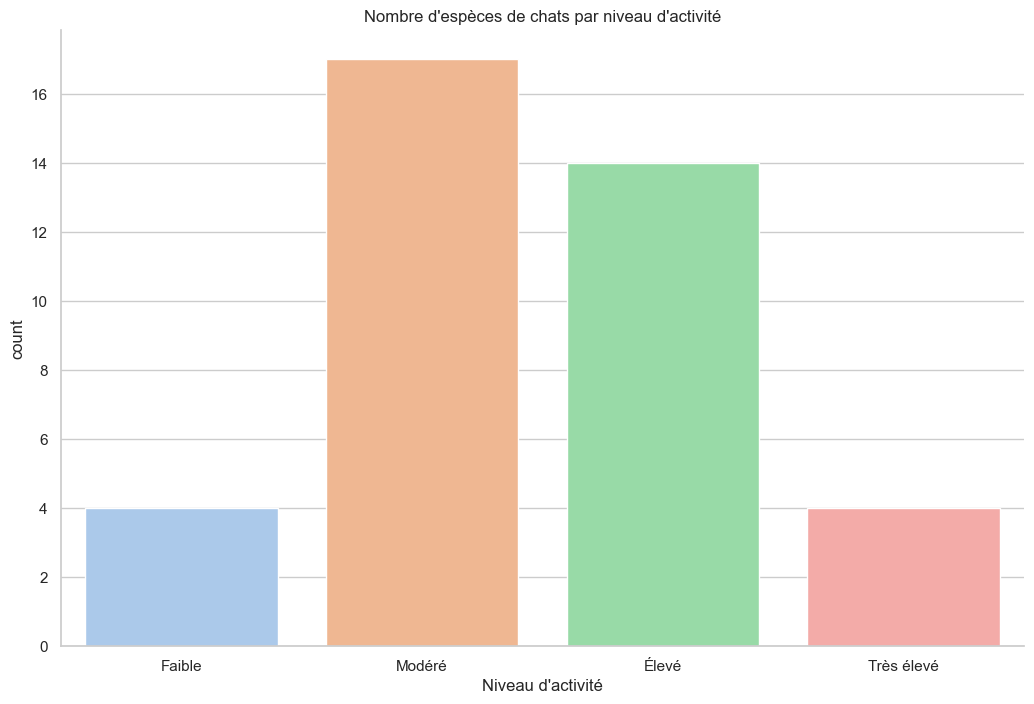

In [6]:
# Activité
ordre_activite = ["Faible", "Modéré", "Élevé", "Très élevé"]
sns.catplot(data=df, x="Niveau d'activité", kind="count",
            order=ordre_activite, palette="pastel", height=7, aspect=1.5)
plt.title("Nombre d'espèces de chats par niveau d'activité")
plt.savefig(FIGURE_DIR / "activite.png")
plt.show()

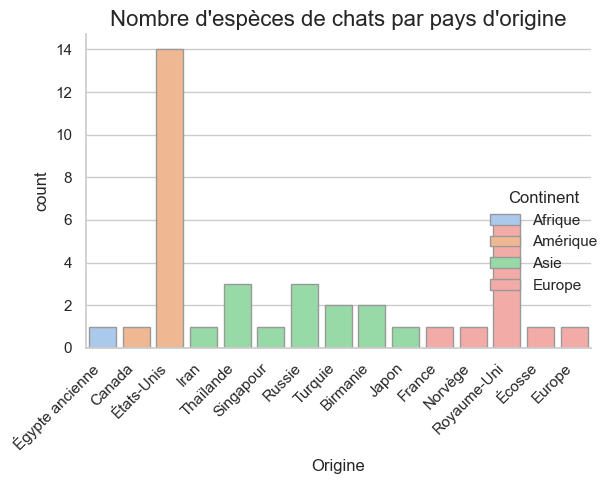

In [7]:
# Origine / continent (pays regroupés par continent pour une lecture plus claire)
ordre_continent = df.sort_values('Continent')["Origine"].unique()
sns.catplot(data=df, x="Origine", kind="count", palette="pastel",
            hue="Continent", edgecolor=".6", order=ordre_continent)
plt.xticks(rotation=45, ha='right')
plt.title("Nombre d'espèces de chats par pays d'origine", fontsize=16)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pays.png")
plt.show()

/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_18938/2633642946.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x="Santé", kind="count",


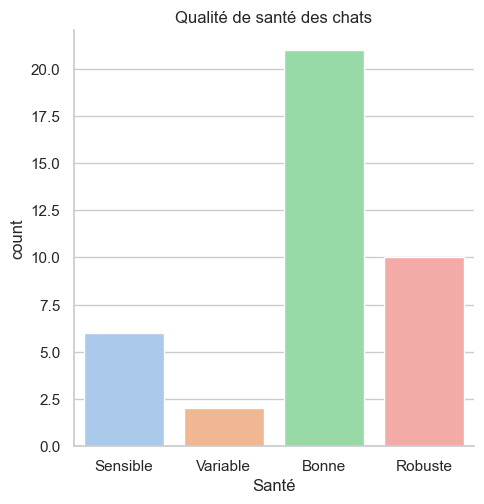

In [8]:
# Santé
ordre_sante = ["Sensible", "Variable", "Bonne", "Robuste"]
sns.catplot(data=df, x="Santé", kind="count",
            order=ordre_sante, palette="pastel")
plt.title("Qualité de santé des chats")
plt.savefig(FIGURE_DIR / "sante.png")
plt.show()

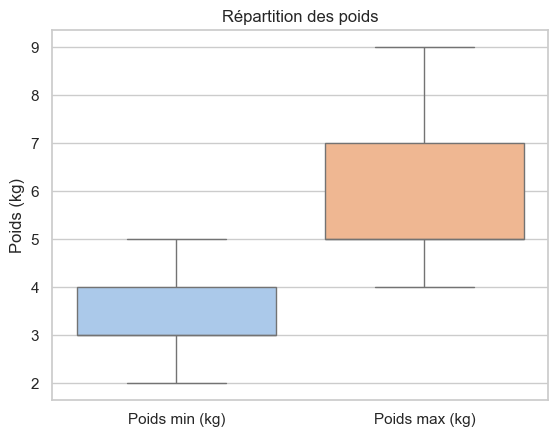

In [9]:
# Boxplot poids
sns.boxplot(data=df[['Poids min (kg)', 'Poids max (kg)']], palette="pastel")
plt.title("Répartition des poids")
plt.ylabel("Poids (kg)")
plt.savefig(FIGURE_DIR / "repartition_poids.png")
plt.show()

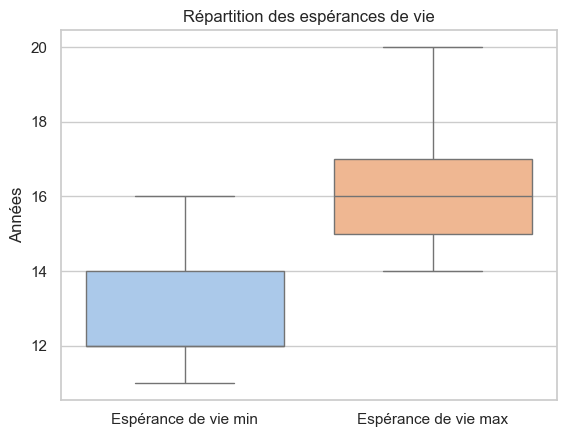

In [10]:
# Boxplot espérance de vie
sns.boxplot(data=df[['Espérance de vie min', 'Espérance de vie max']], palette="pastel")
plt.title("Répartition des espérances de vie")
plt.ylabel("Années")
plt.savefig(FIGURE_DIR / "repartition_vie.png")
plt.show()

/var/folders/p4/c_5q0_7x3ps5z6_phh6r8cb80000gn/T/ipykernel_18938/2595396604.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_caracteres.values, y=top_caracteres.index, palette="pastel")


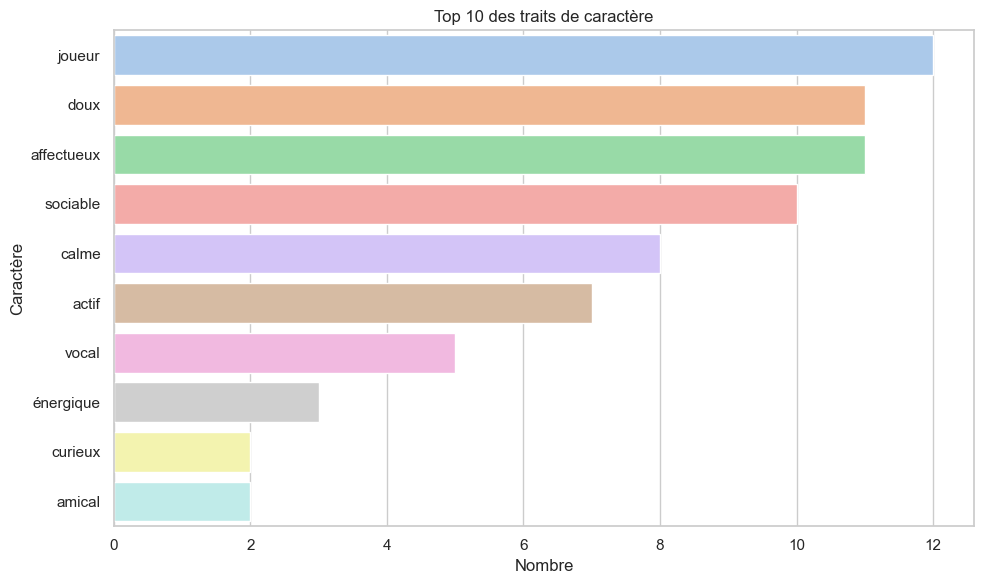

In [11]:
# Top caractères
caracteres = df['Caractère'].str.lower().str.split(', ').explode()
top_caracteres = caracteres.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_caracteres.values, y=top_caracteres.index, palette="pastel")
plt.title("Top 10 des traits de caractère")
plt.xlabel("Nombre")
plt.ylabel("Caractère")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "top_caracteres.png")
plt.show()